# Central and upwind differences for advection–diffusion

Compare finite-difference solutions of a steady **advection–diffusion** boundary value problem. On a coarse grid, central differencing of advection produces oscillations, upwind differencing follows the flow direction and gives a monotone solution.

## 1. Problem statement

A scalar $\phi(x)$ is transported with constant velocity $u$ and diffusion coefficient $D$ on $0\leq x\leq L$:

$$u\frac{d\phi}{dx}=D\frac{d^2\phi}{dx^2}, \qquad \phi(0)=0, \qquad \phi(L)=1.$$

Use $L=1$, $u=1$, and $D=0.01$. Because $u>0$, the flow is from left to right. On a grid with spacing $h=L/(n-1)$, the **grid Péclet number** is $Pe=uh/D$. We begin with $n=11$, so $Pe=10>2$.

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np

# Problem parameters
L = 1.0
u = 1.0
D = 0.01
phi_left = 0.0
phi_right = 1.0
n_coarse = 11  # number of grid points, including both boundaries

h_coarse = L / (n_coarse - 1)
Pe_coarse = u * h_coarse / D
print(f"Coarse-grid spacing h = {h_coarse:.2f}, grid Pe = {Pe_coarse:.1f}")


Coarse-grid spacing h = 0.10, grid Pe = 10.0


## 2. Build the two finite-difference systems

For the diffusion term, both methods use the central second derivative:

$$\left.\frac{d^2\phi}{dx^2}\right|_i\approx\frac{\phi_{i-1}-2\phi_i+\phi_{i+1}}{h^2}.$$

The **central scheme** also uses $(\phi_{i+1}-\phi_{i-1})/(2h)$ for advection. After multiplying the equation by $h^2/D$ and moving all terms to one side, its interior row is

$$(1+Pe/2)\phi_{i-1}-2\phi_i+(1-Pe/2)\phi_{i+1}=0.$$

When $Pe>2$, the coefficient $1-Pe/2$ is negative. This can cause a nonphysical, alternating solution.

The **upwind scheme** uses $(\phi_i-\phi_{i-1})/h$ for $u>0$ and $(\phi_{i+1}-\phi_i)/h$ for $u<0$. For the positive velocity in this example, its interior row is

$$(1+Pe)\phi_{i-1}-(2+Pe)\phi_i+\phi_{i+1}=0.$$

As in the other Lecture 6 notebooks, we solve only for the unknown interior values. The boundary values are moved to the right-hand-side vector $b$.

In [ ]:
def build_fd_matrix(L: float, u: float, D: float, phi_left: float,
                    phi_right: float, nsteps: int,
                    scheme: str) -> tuple[np.ndarray, np.ndarray]:
    """Build A and b for central or upwind steady advection-diffusion.

    Parameters
    ----------
    L : float
        Length of the domain
    u : float
        Constant velocity (positive means flow to the right)
    D : float
        Diffusion coefficient
    phi_left, phi_right : float
        Dirichlet boundary values
    nsteps : int
        Number of grid points, including both boundaries
    scheme : str
        Either "central" or "upwind" for the advection term

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        System matrix A and right-hand-side vector b for phi[1:-1]
    """
    h = L / (nsteps - 1)
    Pe = u * h / D
    n_unknown = nsteps - 2
    A = np.zeros((n_unknown, n_unknown))
    b = np.zeros(n_unknown)

    if scheme == "central":
        left = 1 + Pe / 2
        middle = -2
        right = 1 - Pe / 2
    elif scheme == "upwind":
        if u >= 0:
            left = 1 + Pe
            middle = -2 - Pe
            right = 1
        else:
            left = 1
            middle = -2 + Pe
            right = 1 - Pe
    else:
        raise ValueError("scheme must be 'central' or 'upwind'")

    for i in range(n_unknown):
        A[i, i] = middle
        if i > 0:
            A[i, i - 1] = left
        if i < n_unknown - 1:
            A[i, i + 1] = right

    b[0] -= left * phi_left
    b[-1] -= right * phi_right
    return A, b


## 3. Solve on the coarse grid

Build $A$ and $b$ for each scheme, call `np.linalg.solve`, and add the two known boundary values to each solution.

In [6]:
# central scheme for advection
x_coarse = np.linspace(0.0, L, n_coarse)

A_central, b_central = build_fd_matrix(
    L, u, D, phi_left, phi_right, n_coarse, "central"
)
phi_central = np.zeros(n_coarse)
phi_central[0] = phi_left
phi_central[1:-1] = np.linalg.solve(A_central, b_central)
phi_central[-1] = phi_right

# upwind scheme for advection
A_upwind, b_upwind = build_fd_matrix(
    L, u, D, phi_left, phi_right, n_coarse, "upwind"
)
phi_upwind = np.zeros(n_coarse)
phi_upwind[0] = phi_left
phi_upwind[1:-1] = np.linalg.solve(A_upwind, b_upwind)
phi_upwind[-1] = phi_right

## 4. Compare with the analytical solution

For these boundary values, the exact solution is

$$\phi(x)=\frac{e^{ux/D}-1}{e^{uL/D}-1}.$$

The central solution on the coarse grid alternates above and below the physical range $[0,1]$. Upwind remains monotone, although its first-order advection stencil smears the steep layer near $x=L$.

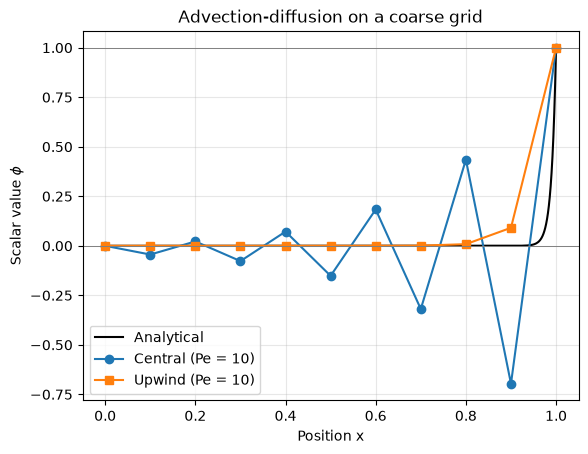

In [4]:
x_exact = np.linspace(0.0, L, 501)
phi_exact = np.expm1(u * x_exact / D) / np.expm1(u * L / D)

fig, ax = plt.subplots()
ax.plot(x_exact, phi_exact, "k-", label="Analytical")
ax.plot(x_coarse, phi_central, "o-", label=f"Central (Pe = {Pe_coarse:.0f})")
ax.plot(x_coarse, phi_upwind, "s-", label=f"Upwind (Pe = {Pe_coarse:.0f})")
ax.axhline(0, color="gray", linewidth=0.7)
ax.axhline(1, color="gray", linewidth=0.7)
ax.set(xlabel="Position x", ylabel="Scalar value $\phi$",
       title="Advection-diffusion on a coarse grid")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 5. Refine the grid

With $n=101$, the spacing is ten times smaller and $Pe=1<2$. The central scheme no longer oscillates. Compare it with the analytical profile on the refined grid.

Fine-grid Pe = 1.0; central solution monotone = True


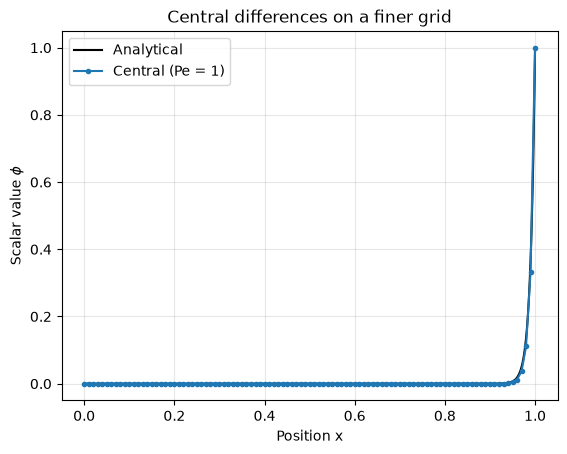

In [5]:
n_fine = 101
x_fine = np.linspace(0.0, L, n_fine)
Pe_fine = u * L / ((n_fine - 1) * D)
A_fine, b_fine = build_fd_matrix(
    L, u, D, phi_left, phi_right, n_fine, "central"
)
phi_fine = np.zeros(n_fine)
phi_fine[0] = phi_left
phi_fine[1:-1] = np.linalg.solve(A_fine, b_fine)
phi_fine[-1] = phi_right

print(f"Fine-grid Pe = {Pe_fine:.1f}; central solution monotone = "
      f"{np.all(np.diff(phi_fine) >= -1e-12)}")

fig, ax = plt.subplots()
ax.plot(x_exact, phi_exact, "k-", label="Analytical")
ax.plot(x_fine, phi_fine, "o-", markersize=3,
        label=f"Central (Pe = {Pe_fine:.0f})")
ax.set(xlabel="Position x", ylabel="Scalar value $\phi$",
       title="Central differences on a finer grid")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
